## Análise de comércio internacional do Ceará

Esse projeto tem por objetivo a geração de insights sobre movimentações para exportação de carga nos portos do Ceará.

Os dados são de disponibilidade pública e foram obtidos do site www.basedosdados.org.

Os comentários técnicos são feitos dentro de cada célula de código.

### Configurações gerais

In [18]:
#importação das bibliotecas necessárias

import os
import pandas as pd
import matplotlib.pyplot as plt
import textwrap
import basedosdados as bd #para conexão com a base de dados
from dotenv import load_dotenv #para ler o arquivo que contém o ID do projeto no google bigquery



In [3]:
#configuração do project ID
load_dotenv()

# O trecho abaixo lê de um outro arquivo o id do projeto. Por questões de segurança dos dados esse arquivo externo não será disponibilizado publicamente.
# Para mais informações sobre como replicar esse projeto consulte o arquivo README.md

project_id = os.getenv("google_id_do_projeto") #SUBSTITUA ESSE CÓDIGO PELO SEU ID PARA REPLICAR O PROJETO


### Principais destinos das exportações cearenses

Aqui entende-se quais são os principais parceiros comerciais das exportações. Essa análise visa identificar se há dependência de um país na economia do Estado.

In [ ]:
query = """
SELECT 
    nomeclatura_pais.nome AS destino,  -- destino do produto
    nomeclatura_sh.nome_sh4_portugues AS produto,  -- nome do produto
    SUM(exportacao.valor_fob_dolar) AS valor_USD  -- Valor total das exportações (em dólares)

FROM `basedosdados.br_me_comex_stat.ncm_exportacao` AS exportacao 


-- esses joins são para traduzir o nome dos produtos. Necessário usar tabela intermediária on sh6 para tradução do código sh4
JOIN `basedosdados.br_bd_diretorios_mundo.nomenclatura_comum_mercosul` AS nomeclatura_mercosul_intermediario  
  ON exportacao.id_ncm = nomeclatura_mercosul_intermediario.id_ncm
JOIN `basedosdados.br_bd_diretorios_mundo.sistema_harmonizado` AS nomeclatura_sh 
  ON nomeclatura_mercosul_intermediario.id_sh6 = nomeclatura_sh.id_sh6

-- esse join é para traduzir a UF de origem e permitir selecionar apenas o estado do Ceará
LEFT JOIN (SELECT DISTINCT sigla,nome  FROM `basedosdados.br_bd_diretorios_brasil.uf`) AS diretorio_sigla_uf_ncm 
  ON exportacao.sigla_uf_ncm = diretorio_sigla_uf_ncm.sigla

-- esse join é para traduzir o nome dos países
JOIN `basedosdados.br_bd_diretorios_mundo.pais` AS nomeclatura_pais   
  ON exportacao.sigla_pais_iso3 = nomeclatura_pais.sigla_pais_iso3   

-- esse join serve para identificar a via de exportação e permitir a seleção apenas da via marítima
LEFT JOIN `basedosdados.br_me_comex_stat.dicionario` AS dic  
  ON exportacao.id_via = dic.chave
  AND dic.nome_coluna = 'id_via'
  AND dic.id_tabela = 'ncm_exportacao'

WHERE exportacao.ano BETWEEN 2015 AND 2025 -- limitador de 10 anos

GROUP BY produto, destino, diretorio_sigla_uf_ncm.nome, dic.valor

HAVING 
  diretorio_sigla_uf_ncm.nome = 'Ceará' -- limitador de exportações apenas do estado do Ceará
  AND dic.valor = 'Maritima'  -- limitador de exportações via marítima

ORDER BY valor_USD DESC  -- Para organizar por ordem de valor total de vendas
LIMIT 20
"""

df = bd.read_sql(
    query,  # a query criada acima
    billing_project_id=project_id  # o id do projeto
)

df.head()

Downloading: 100%|██████████|


,destino,produto,valor_USD
0,Estados Unidos,Produtos semimanufacturados de ferro ou aço nã...,4068231198
1,México,Produtos semimanufacturados de ferro ou aço nã...,1836091216
2,Estados Unidos,"Outras ligas de aço, em lingotes ou outras for...",909044838
3,Turquia,Produtos semimanufacturados de ferro ou aço nã...,557979203
4,Coreia do Sul,Produtos semimanufacturados de ferro ou aço nã...,533761469


In [5]:
# somar os valores de cada país para se ter um panorama geral
df_paises = df.groupby("destino")["valor_USD"].sum().reset_index()

# ordenar por valor total
df_paises=df_paises.sort_values(by="valor_USD", ascending=False) # ascending False para organizar por ordem decrescente

# formatar os valores do número para melhor visualização
df_paises["valor_USD"] = df_paises["valor_USD"] / 1_000_000

df_paises.head()

,destino,valor_USD
4,Estados Unidos,7197.885691
7,México,1836.091216
10,Turquia,557.979203
3,Coreia do Sul,533.761469
0,Alemanha,381.126689


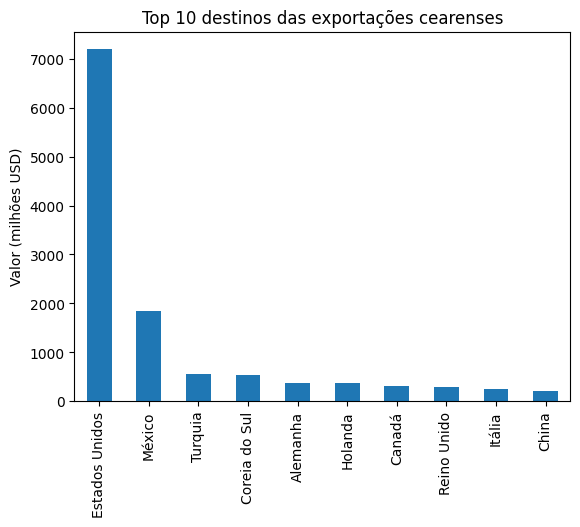

In [6]:
# plotar resultado em gráfico
ax = df_paises.head(10).plot(
    kind="bar",
    x="destino",
    y="valor_USD",
    legend=False
)

plt.title("Top 10 destinos das exportações cearenses")
plt.xlabel("")
plt.ylabel("Valor (milhões USD)")
# plt.xticks(rotation=45)


plt.show()

Nota-se um claro destaque de EUA como principal destino das exportações cearenses. Essa dominância sobre os demais países pode ser uma vulnerabilidade, uma vez que qualquer alteração no regime de comércio com esse país tem um grande impacto na economia estadual. Um exemplo disso são as recentes tarifas impostas pelo governo dos Estados Unidos às importações vinda do Brasil.

Devido ao resultado obtido através do gráfico, é valida uma investigação mais aprofundada sobre o que compõe esse volume de importações para os Estados Unidos.

In [7]:
# gráfico investigativo das importações para os Estados Unidos

df_us = df[df["destino"]=="Estados Unidos"].copy() # novo df para selecionar apenas as exportações para EUA

df_us["valor_USD"] = df_us["valor_USD"] / 1_000_000 # formatar o valor exportado em milhões de dólares para facilitar visualização
df_us.head()

,destino,produto,valor_USD
0,Estados Unidos,Produtos semimanufacturados de ferro ou aço nã...,4068.231198
2,Estados Unidos,"Outras ligas de aço, em lingotes ou outras for...",909.044838
5,Estados Unidos,Partes reconhecíveis como destinadas às máquin...,444.092779
6,Estados Unidos,Sumos de frutas (incluídos os mostos de uvas) ...,420.398268
7,Estados Unidos,"Cocos, castanha do Brasil e castanha de caju, ...",362.851163


In [30]:
# criar o gráfico
# ax = df_us.head().plot(
#     kind="pie",
#     x="produto",
#     y="valor_USD"
# )

rotulos = df_us.head()["produto"].tolist(),
rotulos = [textwrap.wrap(i, width =20) for i in rotulos],



plt.pie(
    x=df_us.head()["valor_USD"], # o .head() é para pegar apenas o top 5
    explode=[0.03,0,0,0,0], # destaca o produto com maior volume de informação

    labels= rotulos

    # labels=[df_us.iloc[0]["produto"],"","","",""]
    # labels=df_us.head()["produto"]
    # labels=textwrap.wrap(df_us.head()["produto"].astype("string"), width=20)
)

plt.title("top 5 Produtos exportados para os Estados Unidos")
plt.xlabel("")
plt.ylabel("")

plt.show()

AttributeError: 'list' object has no attribute 'expandtabs'

### Diferenças de carga entre os portos

O foco agora é entender as particularidades de cada porto. O estado do Ceará possui 2 portos, e essa análise vem identificar quais são as principais cargas de cada um. A finalidade é fornecer base técnica para decisões logísticas visando direcionar corretamente cada tipo de carga, aumentando assim a eficiência.

### Análise de sazonalidade de cargas

Essa seção analisa a movimentação de cargas sazonais, principalmente frutas e derivados. O objetivo é destacar padrões que ajudem no planejamento logístico, evitando assim gargalos e consequentes prejuízos.

### Os novos parceiros

Existem países que cresceram nas exportações? Identificar esses novos destinos para as mercadorias estaduais tem grande valor. Por isso, esse trecho busca identificar países que tiveram crescimento nas movimentações, fornecendo assim dados sobre o crescimento da economia estadual e podendo orientar políticas públicas e acordos internacionais.